# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is "linear" when the predicted output is a linear combination of the parameters, or coefficients. This means that each feature is multiplied by a weight and summed together. It's "linear" in the parameters, not necessarily in the features themselves.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

The coefficient represents the difference in the predicted outcome between that category and the reference category. If you include an intercept, you drop one category to avoid the dummy variable trap (perfect multicollinearity).


3. Can linear regression be used for classification? Explain why, or why not.

Yes, but it's not ideal because the predicted values aren't bounded between 0 and 1, so they can exceed valid probability ranges. Logistic regression is preferred for classification tasks.

4. What are signs that your linear model is over-fitting?

The model performs very well on training data but significantly worse on test/validation data. A large gap between training and test error is the clearest sign.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity occurs when independent variables are highly correlated, making coefficient estimates unstable. The two-stage least squares technique addresses this by using an instrumental variable to isolate the exogenous variation in the problematic predictor, then regressing the outcome on the fitted values from stage one.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can add polynomial terms (example: x^2), interaction terms, or apply transformations (like log⁡(x)) to your features. The model remains "linear" in its parameters even though the relationship with x is nonlinear.


7. What is the interpretation of the slope coefficient in a linear regression?

For a one-unit increase in the feature x, the predicted value of y changes by the value of the slope coefficient, holding all other variables constant.

8. Compare the train/test split and $k$-fold cross validation.

A train/test split divides data once into two sets, which can be sensitive to how the split is made. k-fold cross validation rotates through k different train/validation splits and averages the results, giving a more reliable estimate of model performance.


9.  How is the $k$ in $k$-fold cross validation typically selected?

k is commonly set to 5 or 10 as a practical default. Larger k gives a better estimate of performance but is more computationally expensive, while smaller k is faster but has higher variance.


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

### Q2.1

                    Price  Review Scores Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378

Most expensive borough on average: Manhattan


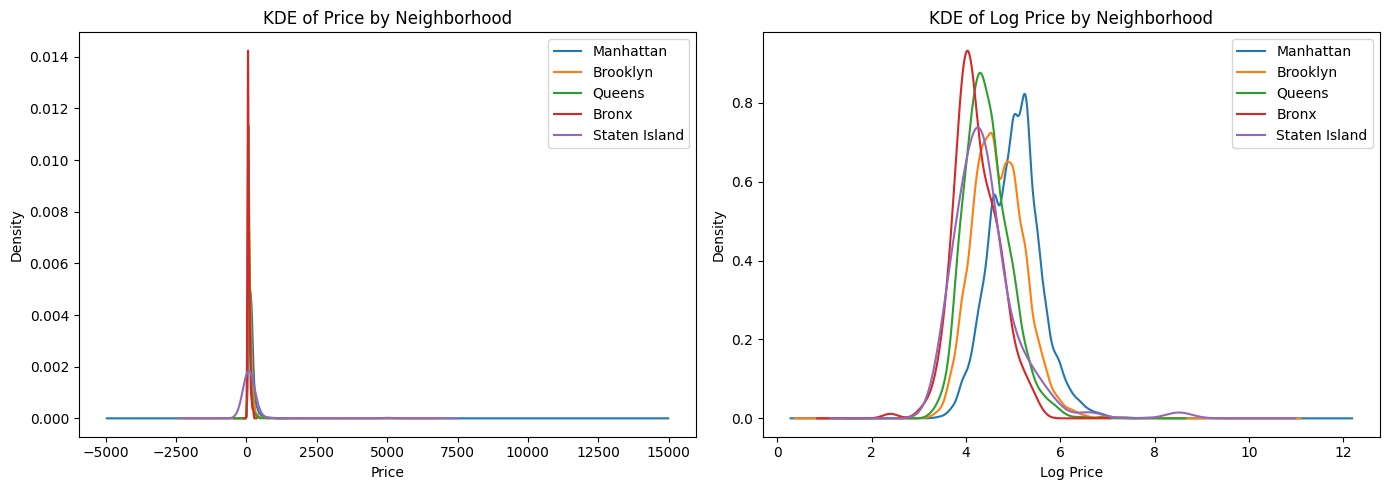

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('./data/Q1_clean.csv')

# Rename column if it has a space
df.rename(columns={' Neighbourhood': 'Neighbourhood'}, inplace=True)
df.columns = df.columns.str.strip()  # strip any whitespace from all column names

# Average price and review score by neighbourhood
avg_by_hood = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean()
print(avg_by_hood.sort_values('Price', ascending=False))
print(f"\nMost expensive borough on average: {avg_by_hood['Price'].idxmax()}")

# KDE plot of Price and Log Price grouped by Neighbourhood
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for neighbourhood in df['Neighbourhood'].unique():
    subset = df[df['Neighbourhood'] == neighbourhood]
    subset['Price'].plot.kde(ax=axes[0], label=neighbourhood)
    np.log1p(subset['Price']).plot.kde(ax=axes[1], label=neighbourhood)

axes[0].set_title('KDE of Price by Neighborhood')
axes[0].set_xlabel('Price')
axes[1].set_title('KDE of Log Price by Neighborhood')
axes[1].set_xlabel('Log Price')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

Manhattan is the most expensive borough on average.

In [22]:
# Q2.2

import statsmodels.api as sm

y_log = np.log1p(df['Price'])

# No intercept, all neighbourhood dummies included
dummies_all = pd.get_dummies(df['Neighbourhood'], drop_first=False).astype(int)

model2b = sm.OLS(y, dummies_all).fit()
print(model2b.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        19:48:08   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Bronx            75.2765      9.868      7.628

I dropped the intercept and kept all dummy variables. This means each coefficient directly represents that borough's average price per night.

Looking at the outputs of 1 and 2, the coefficients are the group means. The coefs of 75.28, 127.75, 183.66, 96.86, and 146.17 match the prices in Q1.1.

Since I dropped the intercept, each coefficient is the conditional mean price for that neighbourhood (avg price listing).

In [29]:
# Q2.3

X3 = sm.add_constant(df['Review Scores Rating'])
model3 = sm.OLS(y_log, X3).fit()
print(model3.summary())

slope = model3.params['Review Scores Rating']

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     302.6
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           2.47e-67
Time:                        19:52:46   Log-Likelihood:                -19281.
No. Observations:               22153   AIC:                         3.857e+04
Df Residuals:                   22151   BIC:                         3.858e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    4.1581 

A coefficient of 0.0076 means that for every 1-point increase in Review Scores Rating, the predicted price increases by approximately 0.76% per night (not a fixed dollar amount because we're using log price).

In [24]:
# Q2.4

dummies = pd.get_dummies(df['Neighbourhood'], drop_first=False).astype(int)

X4 = pd.concat([dummies, df['Review Scores Rating']], axis=1)
model4 = sm.OLS(y_log, X4).fit()
print(model4.summary())

print(f"\nReview Scores Rating coefficient in model3: {model3.params['Review Scores Rating']:.4f}")
print(f"Review Scores Rating coefficient in model4: {model4.params['Review Scores Rating']:.4f}")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     788.9
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:48:24   Log-Likelihood:                -17616.
No. Observations:               22153   AIC:                         3.524e+04
Df Residuals:                   22147   BIC:                         3.529e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Bronx                    3.4908 

Neighbourhood coefficients now represent each borough's mean price **AFTER** controlling for review scores. This is slightly different from Part 2.

The coefficient on Review Scores Rating increases slightly from 0.0076 (Model 3) to 0.0080 (Model 4), meaning after controlling for neighbourhood, each additional rating point is associated with about a 0.80% increase in price. The change is very small, confirming that review scores and neighbourhood are not strongly confounding each other.

The neighbourhood coefficients are in log-dollar units (Bronx: 3.49, Brooklyn: 3.96, Manhattan: 4.32, Queens: 3.73, Staten Island: 3.69) rather than raw dollars, and represent each borough's average log price after controlling for review scores.

In [25]:
# Q2.5 

rating = df['Review Scores Rating']

# Interact rating with each neighbourhood dummy
interactions = dummies.multiply(rating, axis=0)
interactions.columns = [f"{col}_x_Rating" for col in dummies.columns]

X5 = sm.add_constant(pd.concat([interactions], axis=1))
model5 = sm.OLS(y_log, X5).fit()
print(model5.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     779.9
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:48:28   Log-Likelihood:                -17635.
No. Observations:               22153   AIC:                         3.528e+04
Df Residuals:                   22147   BIC:                         3.533e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      4

In [26]:
print("\nSlope (Rating effect) per neighbourhood:")
for col in interactions.columns:
    print(f"  {col.replace('_x_Rating','')}: {model5.params[col]:.4f}")


Slope (Rating effect) per neighbourhood:
  Bronx: 0.0011
  Brooklyn: 0.0062
  Manhattan: 0.0100
  Queens: 0.0036
  Staten Island: 0.0028


The slopes are not similar across neighbourhoods, there is meaningful variation. Manhattan has the steepest slope at 0.0100, meaning a 1-point rating increase is associated with a ~1% price increase, while the Bronx has the flattest slope at 0.0011 (~0.1%). Reviews matter much more in Manhattan than in outer boroughs, which makes sense because there are higher baseline prices and a more competitive market there.

In [28]:
# Q2.6

from sklearn.model_selection import KFold

def cv_rmse_dollars(X, k=10):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    errors = []
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_log.iloc[train_idx], y_log.iloc[test_idx]
        
        model = LinearRegression(fit_intercept=False)
        model.fit(X_train, y_train)
        
        # Predict in log space, convert back to dollars
        predicted_price = np.expm1(model.predict(X_test))
        actual_price = np.expm1(y_test)
        
        rmse = np.sqrt(np.mean((predicted_price - actual_price) ** 2))
        errors.append(rmse)
    return np.mean(errors)

print(f"Model 4 CV RMSE (dollars): {cv_rmse_dollars(X4):.4f}")
print(f"Model 5 CV RMSE (dollars): {cv_rmse_dollars(X5):.4f}")
print(f"Model 6 CV RMSE (dollars): {cv_rmse_dollars(X6):.4f}")

Model 4 CV RMSE (dollars): 140.9955
Model 5 CV RMSE (dollars): 140.9945
Model 6 CV RMSE (dollars): 140.9767


This output tells us a couple things. It first tells us that all three models perform nearly identically (differences less than $1). It also tells us that adding complexity does not help. Model 6 is the most complex model, but it performs slightly worse than the simpler models. Also, the interaction terms don't improve prediction, as M5 is barely better than M4. Lastly, an RMSE of about $141 on NYC prices is very large, meaning that there is a lot of price variation these variables can't explain, such as room type, # of bedrooms, etc.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


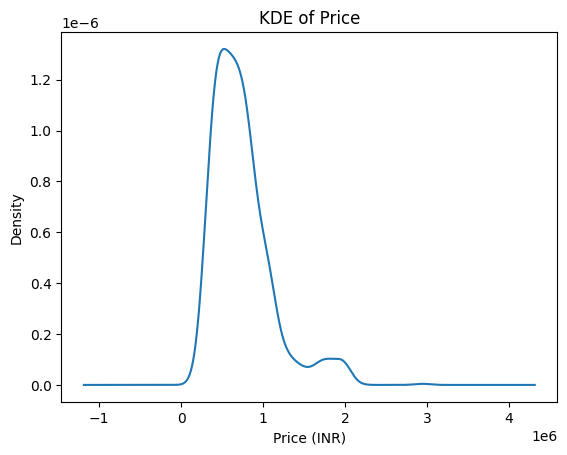

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


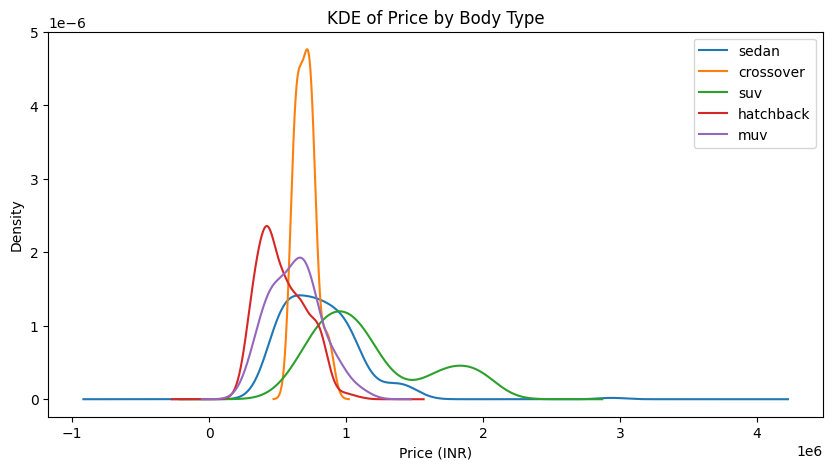

In [30]:
# Q3.1

df = pd.read_csv('./data/cars_hw.csv')

print(df['Price'].describe())

# KDE of Price overall
df['Price'].plot.kde()
plt.title('KDE of Price')
plt.xlabel('Price (INR)')
plt.show()

# Summarize by Body_Type
print(df.groupby('Body_Type')['Price'].describe())

# Grouped KDE by Body_Type
fig, ax = plt.subplots(figsize=(10, 5))
for body in df['Body_Type'].unique():
    df[df['Body_Type'] == body]['Price'].plot.kde(ax=ax, label=body)
ax.set_title('KDE of Price by Body Type')
ax.set_xlabel('Price (INR)')
ax.legend()
plt.show()

SUVs are the most expensive body type on average at ~1.18M INR, followed by sedans at ~810K INR. SUVs also have the most variance with a standard deviation of ~417K INR, visible in the KDE as a wide, flat curve stretching far to the right.

The crossovers are interestingly the least variable body type, showing a very narrow, tall spike in the KDR around 700K INR, meaning their prices are tightly clustered. Hatchbacks are the cheapest on average (~534K INR) and also relatively tightlyb distributed. Sedans have the second highest variance and the longest right tail, indicating some very high-end luxury sedans pulling the distribution right.

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0245
Time:                        20:10:01   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

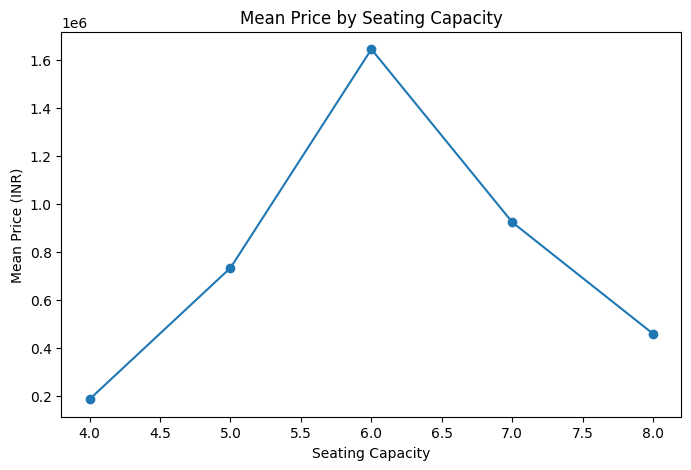

In [32]:
# Q3.2

# Continuous regression
X2_cont = sm.add_constant(df['Seating_Capacity'])
model2_cont = sm.OLS(df['Price'], X2_cont).fit()
print(model2_cont.summary())
print(f"\nSlope: {model2_cont.params['Seating_Capacity']:.2f}")

# Categorical (one-hot encoded) regression
dummies_seats = pd.get_dummies(df['Seating_Capacity'], drop_first=False).astype(int)
model2_cat = sm.OLS(df['Price'], dummies_seats).fit()
print(model2_cat.summary())

# Plot conditional means vs seating capacity to check linearity
seat_means = df.groupby('Seating_Capacity')['Price'].mean()
plt.figure(figsize=(8,5))
plt.plot(seat_means.index, seat_means.values, marker='o')
plt.title('Mean Price by Seating Capacity')
plt.xlabel('Seating Capacity')
plt.ylabel('Mean Price (INR)')
plt.show()

The slope coefficient is 59,270 INR, meaning each additional seat is associated with a ~59,270 INR increase in price. However, with an R² of just 0.005, seating capacity alone explains almost none of the price variation.

The relationship is clearly not linear. As seen in the plot, prices rise from 4 seats (~190K INR) to a sharp peak at 6 seats (~1.65M INR), then drop at 7 (~930K INR) and 8 seats (~460K INR). This inverted-V shape cannot be captured by a single linear slope. Treating seating capacity as categorical is far more appropriate since it allows each seat count to have its own mean price.

Degree 1: CV RMSE = 316694.44
Degree 2: CV RMSE = 317513.18
Degree 3: CV RMSE = 316828.29
Degree 4: CV RMSE = 316977.02
Degree 5: CV RMSE = 316435.37
Degree 6: CV RMSE = 316777.15
Degree 7: CV RMSE = 315926.06
Degree 8: CV RMSE = 315198.87
Degree 9: CV RMSE = 315657.07
Degree 10: CV RMSE = 316066.85


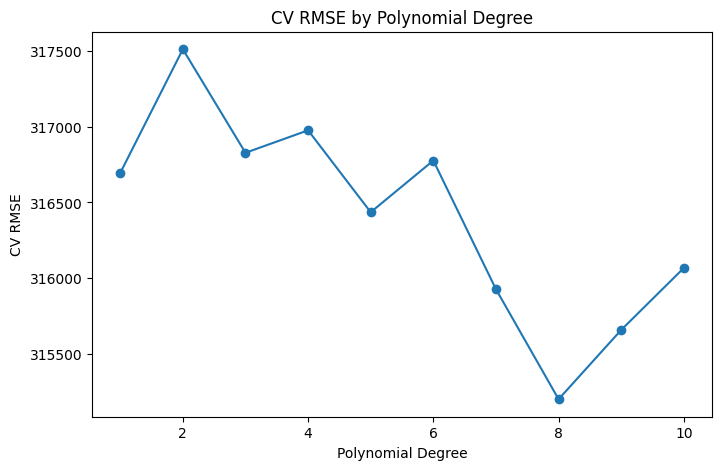


Optimal polynomial degree: 8


In [34]:
# Q3.3 

from sklearn.preprocessing import PolynomialFeatures

# Create Age variable
current_year = 2024
df['Age'] = current_year - df['Make_Year']

# 10-fold CV over polynomial degrees 1 through 10
y = df['Price']
X_age = df[['Age']]
cv_scores = []

for degree in range(1, 11):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_age)
    model = LinearRegression()
    scores = cross_val_score(model, X_poly, y, cv=10, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    cv_scores.append(rmse)
    print(f"Degree {degree}: CV RMSE = {rmse:.2f}")

# Plot CV RMSE vs degree
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), cv_scores, marker='o')
plt.title('CV RMSE by Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('CV RMSE')
plt.show()

optimal_degree = np.argmin(cv_scores) + 1
print(f"\nOptimal polynomial degree: {optimal_degree}")


Degree 8 produced the lowest CV RMSE of 315,198 INR. However, the overall differences between degrees are quite small — the range from best to worst is only ~2,300 INR. This suggests that the polynomial degree doesn't matter that much here. Notably, degree 2 actually performs the worst, and performance generally improves at higher degrees before ticking back up at degree 10, indicating slight overfitting beyond degree 8. The relatively flat CV curve suggests that Age alone is simply not a strong predictor of price regardless of how complex the polynomial gets.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


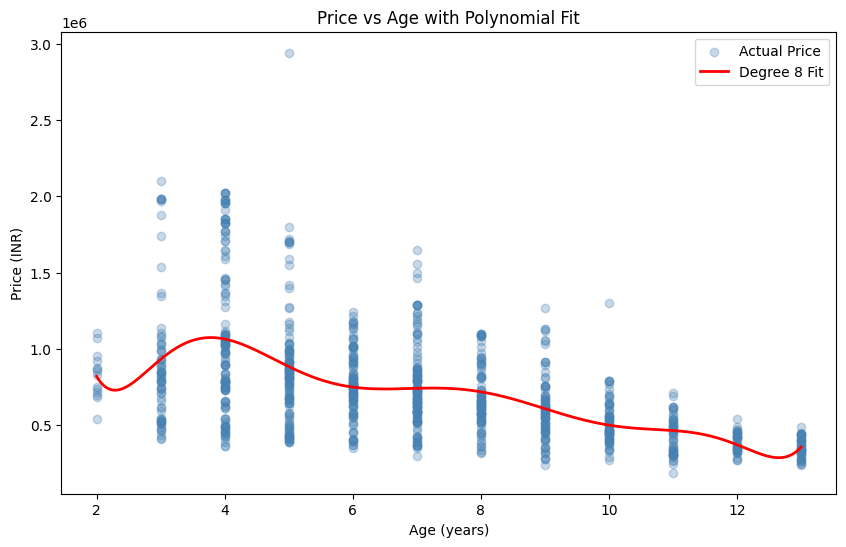

In [35]:
# Q3.4

# Fit optimal model
poly_opt = PolynomialFeatures(degree=optimal_degree, include_bias=False)
X_opt = poly_opt.fit_transform(X_age)
model_opt = LinearRegression()
model_opt.fit(X_opt, y)

# Generate smooth prediction curve
age_range = np.linspace(df['Age'].min(), df['Age'].max(), 300).reshape(-1, 1)
age_range_poly = poly_opt.transform(age_range)
predicted = model_opt.predict(age_range_poly)

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Price'], alpha=0.3, label='Actual Price', color='steelblue')
plt.plot(age_range, predicted, color='red', linewidth=2, label=f'Degree {optimal_degree} Fit')
plt.title('Price vs Age with Polynomial Fit')
plt.xlabel('Age (years)')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

The model shows a slight bump around ages 3-4 before gradually declining, which roughly tracks the average, as newer cars tend to be priced higher. However, there is enormous vertical spread at every age, meaning the model is really only capturing the average trend while missing most of the individual variation. Overall, Age alone is a weak predictor, and other features like body type and seating capacity would be needed for a meaningfully accurate model.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [36]:
# Q4.1

df = pd.read_csv('./data/heart_hw.csv')

# Survival proportions by group
proportions = df.groupby('transplant')['y'].mean()
print(proportions)

control_survival = proportions['control']
treatment_survival = proportions['treatment']
ATE = treatment_survival - control_survival

print(f"\nControl survival rate: {control_survival:.4f}")
print(f"Treatment survival rate: {treatment_survival:.4f}")
print(f"ATE (treatment - control): {ATE:.4f}")

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64

Control survival rate: 0.1176
Treatment survival rate: 0.3478
ATE (treatment - control): 0.2302


The proportion of people who survived in the control group was 0.1176 and in the treatment group was 0.3478. The ATE — computed as 0.3478 minus 0.1176 — is 0.2302. A positive ATE would indicate that transplant recipients were more likely to survive three years than those who did not receive a transplant, while a negative ATE would suggest the transplant group fared worse, possibly due to the risks of the operation itself or post-transplant complications.

In [37]:
# Q4.2

# Create dummy for transplant (treatment=1, control=0)
df['transplant_dummy'] = (df['transplant'] == 'treatment').astype(int)

X = sm.add_constant(df['transplant_dummy'])
model = sm.OLS(df['y'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0133
Time:                        20:29:25   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1176      0.075  

The intercept of 0.1176 equals the control group's survival rate from Part 1, which is the predicted probability of survival for a non-transplant patient. The transplant_dummy coefficient of 0.2302 equals the ATE, meaning transplant recipients had a 23 percentage point higher survival rate than the control group, and this effect is statistically significant (p=0.013). These numbers match Part 1 exactly, confirming that OLS with a single dummy recovers the group means and their difference.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           0.000357
Time:                        21:21:16   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.7020      0.196  

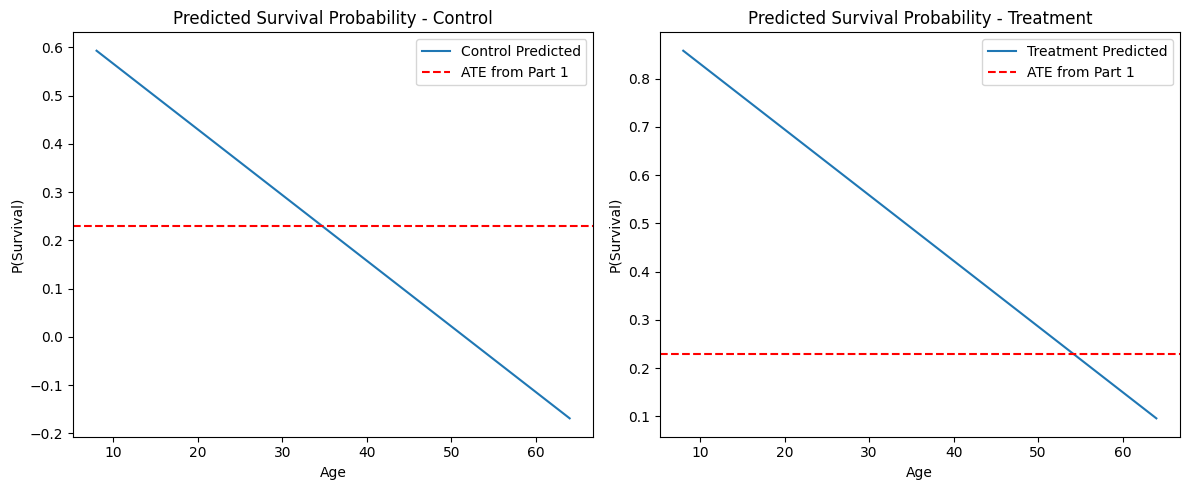

In [38]:
# Q4.3

X3 = sm.add_constant(pd.concat([df['transplant_dummy'], df['age']], axis=1))
model3 = sm.OLS(df['y'], X3).fit()
print(model3.summary())

# Plot predicted probability by age
age_range = np.linspace(df['age'].min(), df['age'].max(), 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (group, val) in enumerate([('Control', 0), ('Treatment', 1)]):
    X_plot = pd.DataFrame({
        'const': 1,
        'transplant_dummy': val,
        'age': age_range
    })
    predicted = model3.predict(X_plot)
    axes[i].plot(age_range, predicted, label=f'{group} Predicted')
    axes[i].axhline(y=ATE, color='red', linestyle='--', label='ATE from Part 1')
    axes[i].set_title(f'Predicted Survival Probability - {group}')
    axes[i].set_xlabel('Age')
    axes[i].set_ylabel('P(Survival)')
    axes[i].legend()

plt.tight_layout()
plt.show()


When controlling for age, the transplant coefficient increases slightly from 0.2302 to 0.2647, meaning the true treatment effect is a bit stronger once we account for age. This shows that older patients were slightly more likely to be in the control group, partially masking the effect. The intercept (0.7020) represents predicted survival for a age=0 patient in the control group, and the age slope (-0.0136) means each additional year reduces survival probability by ~1.4 percentage points.

From the plots, the ATE of 0.2302 is a flat estimate that masks age-based variation. It overestimates the transplant benefit for older patients (roughly above age 40) where predicted survival drops below the dashed line, and underestimates it for younger patients where predicted survival sits well above it.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           0.000310
Time:                        21:24:53   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3549      0.280  

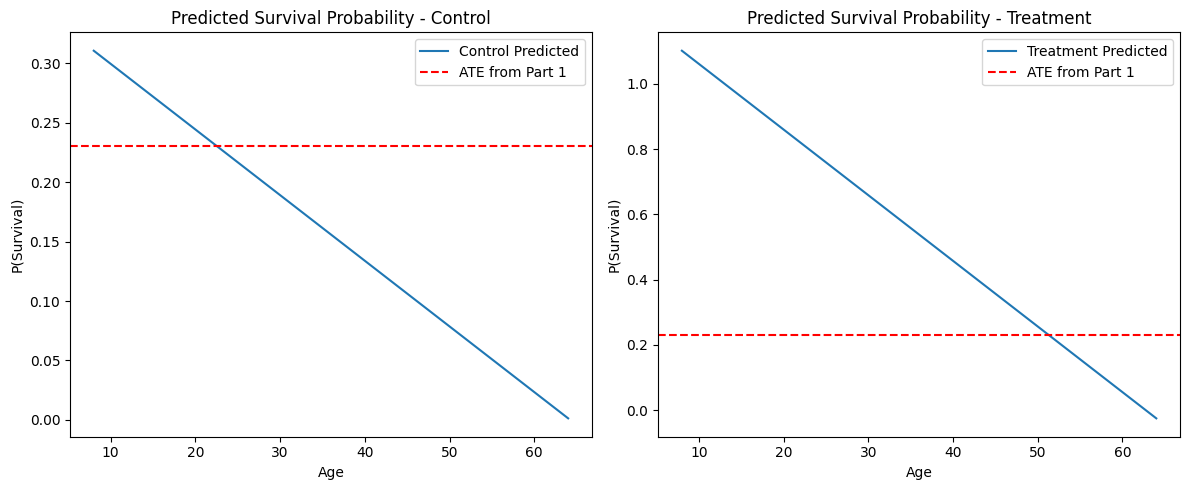

In [39]:
# Q4.4

# Create interaction term
df['transplant_x_age'] = df['transplant_dummy'] * df['age']

X4 = sm.add_constant(pd.concat([df['transplant_dummy'], df['age'], df['transplant_x_age']], axis=1))
model4 = sm.OLS(df['y'], X4).fit()
print(model4.summary())

# Plot predicted probability by age with interaction
age_range = np.linspace(df['age'].min(), df['age'].max(), 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (group, val) in enumerate([('Control', 0), ('Treatment', 1)]):
    X_plot = pd.DataFrame({
        'const': 1,
        'transplant_dummy': val,
        'age': age_range,
        'transplant_x_age': val * age_range
    })
    predicted = model4.predict(X_plot)
    axes[i].plot(age_range, predicted, label=f'{group} Predicted')
    axes[i].axhline(y=ATE, color='red', linestyle='--', label='ATE from Part 1')
    axes[i].set_title(f'Predicted Survival Probability - {group}')
    axes[i].set_xlabel('Age')
    axes[i].set_ylabel('P(Survival)')
    axes[i].legend()

plt.tight_layout()
plt.show()



Adding the interaction term reveals that the transplant benefit decreases with age. The transplant coefficient of 0.9078 represents the benefit at age 0, but the interaction term of -0.0146 means this benefit shrinks by ~1.5 percentage points per additional year of age.

The key pattern is that the two groups now have different slopes. Treatment group survival declines much more steeply with age. Younger patients benefit greatly from a transplant, while for older patients (above ~50) the two groups converge, suggesting transplants offer little survival advantage for older recipients.

In [40]:
# Q4.5

X2_cv = pd.concat([df['transplant_dummy']], axis=1)
X3_cv = pd.concat([df['transplant_dummy'], df['age']], axis=1)
X4_cv = pd.concat([df['transplant_dummy'], df['age'], df['transplant_x_age']], axis=1)
y_cv = df['y']

def cv_rmse(X, y, k=10):
    model = LinearRegression()
    scores = cross_val_score(model, X, y, cv=k, scoring='neg_mean_squared_error')
    return np.sqrt(-scores.mean())

print(f"Model 2 (transplant only) CV RMSE:            {cv_rmse(X2_cv, y_cv):.4f}")
print(f"Model 3 (transplant + age) CV RMSE:           {cv_rmse(X3_cv, y_cv):.4f}")
print(f"Model 4 (transplant + age + interaction) RMSE:{cv_rmse(X4_cv, y_cv):.4f}")

Model 2 (transplant only) CV RMSE:            0.4579
Model 3 (transplant + age) CV RMSE:           0.4463
Model 4 (transplant + age + interaction) RMSE:0.4428


Each model improves slightly on the previous one. Adding age reduces RMSE from 0.4579 to 0.4463, and adding the interaction term reduces it further to 0.4428. However, the improvements are marginal, suggesting that while age and its interaction with transplant status do add some predictive value, none of these models explain survival particularly well on their own.

### Q4.6

Using this model to prioritize transplant access raises several serious concerns. First, the model is extremely simple, as it only uses age and transplant status, ignoring critical medical factors like disease severity, overall health, or any pre-existing conditions. A patient denied a transplant based on age alone could be much healthier than a younger patient the model favors. The concern is that an older patient who could genuinely benefit from a transplant gets denied simply because the model predicts diminishing returns with age. Further, the data likely suffers from selection bias. This means that patients who received transplants may have been systematically healthier or younger to begin with, meaning the observed treatment effect doesn't purely reflect the transplant's impact. Third, the model predicts average survival probabilities, which is inappropriate for individual-level allocation decisions. Two patients with the same age could have vastly different outcomes. Finally, using predicted survival to allocate organs creates a troubling ethical feedback loop where older or sicker patients are systematically deprioritized. A model this simple should never be used for high-stakes medical decisions without significant additional validation, other factors being put into play, clinical oversight, and ethical review.